Repeated Gradient Descent (RGD) for performative prediction.

Like PerfGD, but only using the first-order gradient (dL1) without 
the performative correction term (dL2).

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from typing import Callable
from collections import deque
import torch

In [2]:
def RGD(
    f_hat: Callable,
    D_theta: Callable,
    loss: Callable,
    theta_0: torch.Tensor,
    proj_theta: Callable = lambda x: x,
    n: int = 5000,
    eta: float = 0.0001,
    tol: float = 1e-5,
    max_iter: int = 5000
):

    all_thetas = [theta_0.clone().detach().squeeze()]
    
    theta_t = theta_0
    converged = False
    t = 0
    
    while not converged and t < max_iter:
        # Draw n samples from D(theta)
        z = D_theta(theta_t, n)
        
        # Compute gradient of loss (dL1)
        theta_t.requires_grad_(True)
        theta_t.grad = None 
        l_t = loss(z, theta_t).mean(dim=-1)
        l_t.backward()
        dL1 = theta_t.grad
        
        with torch.no_grad():
            theta_t = proj_theta(theta_t - eta * dL1)
        
        all_thetas.append(theta_t.detach().squeeze())
        
        # Check convergence
        if dL1.norm() < tol: 
            converged = True
        
        t += 1
    
    return theta_t, all_thetas

In [3]:
def PerfGD(
    f_hat: Callable,
    grad2_est: Callable,
    D_theta: Callable,
    loss: Callable,
    theta_0: torch.Tensor,
    proj_theta: Callable = lambda x: x,
    n: int = 5000,
    eta: float = 0.0001,
    H: int = 4,
    tol: float = 1e-5,
    max_iter: int = 5000
):
    
    all_thetas = [theta_0.clone().detach().squeeze()]

    theta_history = deque(maxlen=H)
    f_history = deque(maxlen=H)

    # First take H steps of RGD
    theta_t = theta_0
    for t in range(H):

        z = D_theta(theta_t, n) # Draw n samples from D(theta)
        f_t = f_hat(z)  # Estimate for f(theta)

        theta_history.append(theta_t.detach())
        f_history.append(f_t.detach())

        # Gradient descent step on Loss_1 loss
        theta_t.requires_grad_(True)
        theta_t.grad = None 
        l_t = loss(z, theta_t).mean(dim=-1)
        l_t.backward()
        dL1 = theta_t.grad

        with torch.no_grad():
            theta_t = proj_theta(theta_t - eta * dL1)

        all_thetas.append(theta_t.detach().squeeze())

    # Not run with full gradient update
    converged = False
    t = H
    while not converged:

        z = D_theta(theta_t, n) # Draw n samples from D(theta) (d x n)
        f_t = f_hat(z) # (d,)
        
        theta_history.append(theta_t.detach())
        f_history.append(f_t.detach())

        theta_t.requires_grad_(True)
        theta_t.grad = None 
        l_t = loss(z, theta_t).mean(dim=-1)
        l_t.backward()
        dL1 = theta_t.grad
        
        Theta_full = torch.stack([th for th in theta_history], dim=1)   # (p, ≤H+1)
        F_full = torch.stack([fh for fh in f_history], dim=1)   # (q, ≤H+1)
        
        Theta = Theta_full[:, :-1]                                      # (p, H) -> t-H : t-1
        F = F_full[:, :-1]
        oneH = torch.ones(1, Theta.shape[1], device=Theta.device)

        delta_theta = Theta - theta_t.unsqueeze(1) @ oneH          # (p, H)
        delta_f = F - f_t.unsqueeze(1) @ oneH          # (q, H)

        df_d_theta = delta_f @ torch.linalg.pinv(delta_theta) # (p x q)

        dL2 = grad2_est(z, f_t, theta_t, df_d_theta)

        with torch.no_grad():
            theta_t = proj_theta(theta_t - eta * (dL1 + dL2))

        all_thetas.append(theta_t.detach().squeeze())
        
        if (dL1 + dL2).norm() < tol: 
            break # Converged
        
        t += 1
        if t > max_iter: 
            break # Max iterations
    
    return theta_t, all_thetas

### Example 5.1: Mixture of Gaussians and nonlinear mean

#### Nonlinear Mean

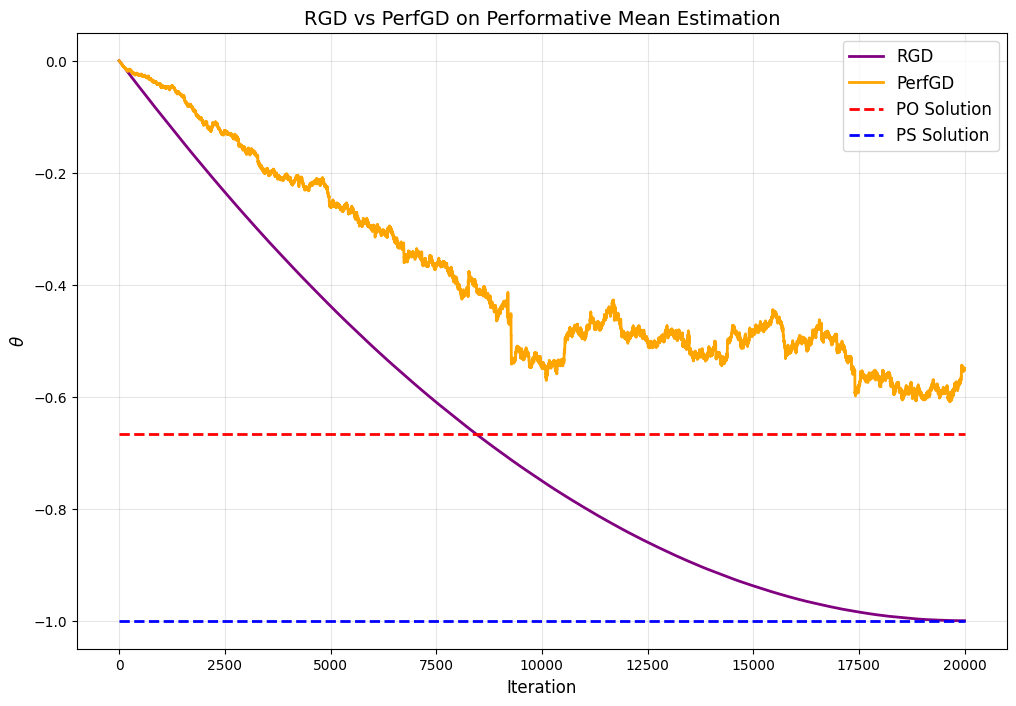

In [4]:
a0 = 1.0
a1 = 1.0
sigma = torch.tensor([[1.0]])
mu = lambda theta: torch.sqrt(a0*theta + a1) # Define mean function (determines performativity)
f_hat = lambda z: z.mean(dim=1)
D_theta = lambda theta, n: torch.normal(mu(theta).squeeze(), 1.0, size=(1,n))
loss = lambda z, theta: z*theta
def grad2_est(z, f, theta, df_d_theta):
    if z.ndim == 1: z = z.unsqueeze(0)
    if f.ndim == 1: f = f.unsqueeze(0)
    return torch.mean( loss(z, theta) * (df_d_theta.T @ torch.linalg.inv(sigma) @ (z - f)), dim=-1)

proj_theta = lambda x: x.clamp(min=-1.0, max=1.0)

# Run RGD
theta_rgd, all_theta_rgd = RGD(
    f_hat,
    D_theta,
    loss,
    theta_0 = torch.tensor([0.0]),
    proj_theta = proj_theta,
    n = 500,
    eta = 0.0001,
    tol = 1e-8,
    max_iter = 20000
)

# Run PerfGD
theta_perfgd, all_theta_perfgd = PerfGD(
    f_hat,
    grad2_est,
    D_theta,
    loss,
    theta_0 = torch.tensor([0.0]),
    proj_theta = proj_theta,
    n = 500,
    eta = 0.0001,
    H = 4,
    tol = 1e-8,
    max_iter = 20000
)

# Plot both results
plt.figure(figsize=(12, 8))
plt.plot(torch.stack(all_theta_rgd), label='RGD', linewidth=2, color='purple')
plt.plot(torch.stack(all_theta_perfgd), label='PerfGD', linewidth=2, color='orange')
plt.hlines(-2*a0/(3*a1), 0, max(len(all_theta_rgd), len(all_theta_perfgd)), 
           colors='r', linestyles='dashed', label='PO Solution', linewidth=2)
plt.hlines(-a0/a1, 0, max(len(all_theta_rgd), len(all_theta_perfgd)), 
           colors='b', linestyles='dashed', label='PS Solution', linewidth=2)
plt.legend(fontsize=12)
plt.title('RGD vs PerfGD on Performative Mean Estimation', fontsize=14)
plt.xlabel('Iteration', fontsize=12)
plt.ylabel(r'$\theta$', fontsize=12)
plt.grid(True, alpha=0.3)
plt.show()

### Mixture of Gaussians

PerfGD completed. Final theta: -0.337648
RGD trajectory length: 100001
PerfGD trajectory length: 100002


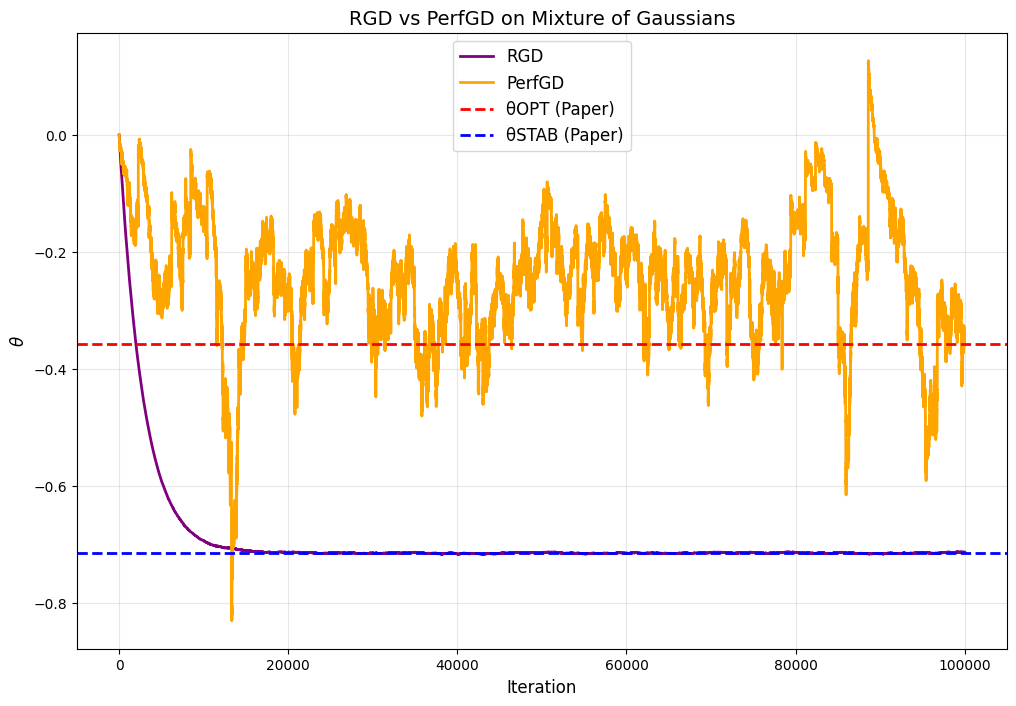

In [15]:
# Mixture of Gaussians example
# Parameters from PerfGD paper Appendix E.1
gamma = 0.5
sigma1_sq = 1.0
sigma2_sq = 0.25
a1_0 = -0.5
a1_1 = 1.0
a2_0 = 1.0
a2_1 = -0.3

# Component means as functions of theta
mu1 = lambda theta: a1_0 + a1_1 * theta  # First component mean
mu2 = lambda theta: a2_0 + a2_1 * theta  # Second component mean

# Define the mixture distribution
def D_theta_mixture(theta, n):
    # Sample from mixture of Gaussians
    n1 = int(gamma * n)
    n2 = n - n1
    
    # Sample from first component
    z1 = torch.normal(mu1(theta).squeeze(), torch.sqrt(torch.tensor(sigma1_sq)), size=(1, n1))
    # Sample from second component  
    z2 = torch.normal(mu2(theta).squeeze(), torch.sqrt(torch.tensor(sigma2_sq)), size=(1, n2))
    
    # Combine samples
    z = torch.cat([z1, z2], dim=1)
    return z

# Estimator function (sample mean)
f_hat_mixture = lambda z: z.mean(dim=1)

# Loss function
loss_mixture = lambda z, theta: z * theta

# Gradient estimation function for PerfGD
def grad2_est_mixture(z, f, theta, df_d_theta):
    if z.ndim == 1: z = z.unsqueeze(0)
    if f.ndim == 1: f = f.unsqueeze(0)
    # For mixture, we need to account for the mixture structure
    sigma_mixture = torch.tensor([[sigma1_sq]])  # Use first component variance
    return torch.mean(loss_mixture(z, theta) * (df_d_theta.T @ torch.linalg.inv(sigma_mixture) @ (z - f)), dim=-1)

# Projection function
proj_theta_mixture = lambda x: x.clamp(min=-1.0, max=1.0)


theta_rgd_mix, all_theta_rgd_mix = RGD(
    f_hat_mixture,
    D_theta_mixture,
    loss_mixture,
    theta_0=torch.tensor([0.0]),
    proj_theta=proj_theta_mixture,
    n=1000,  # Paper uses n=1000
    eta=0.001,  # Paper uses eta=0.1
    tol=1e-8,
    max_iter=100000
)

theta_perfgd_mix, all_theta_perfgd_mix = PerfGD(
    f_hat_mixture,
    grad2_est_mixture,
    D_theta_mixture,
    loss_mixture,
    theta_0=torch.tensor([0.0]),
    proj_theta=proj_theta_mixture,
    n=1000,  # Paper uses n=1000
    eta=0.001,  # Paper uses eta=0.1
    H=4,
    tol=1e-8,
    max_iter=100000
)
print(f"PerfGD completed. Final theta: {theta_perfgd_mix.item():.6f}")

# Plot results
plt.figure(figsize=(12, 8))

# Debug: Check if trajectories exist
print(f"RGD trajectory length: {len(all_theta_rgd_mix)}")
print(f"PerfGD trajectory length: {len(all_theta_perfgd_mix)}")

# Plot algorithm trajectories
if len(all_theta_rgd_mix) > 0:
    plt.plot(torch.stack(all_theta_rgd_mix), label='RGD', linewidth=2, color='purple')
else:
    print("Warning: RGD trajectory is empty")

if len(all_theta_perfgd_mix) > 0:
    plt.plot(torch.stack(all_theta_perfgd_mix), label='PerfGD', linewidth=2, color='orange')
else:
    print("Warning: PerfGD trajectory is empty")

# Add theoretical solutions from paper Appendix E.1
# θOPT = -0.5 * (γ*a1,0 + (1-γ)*a2,0) / (γ*a1,1 + (1-γ)*a2,1)
# θSTAB = (γ*a1,0 + (1-γ)*a2,0) / (γ*a1,1 + (1-γ)*a2,1)
theta_opt = -0.5 * (gamma * a1_0 + (1 - gamma) * a2_0) / (gamma * a1_1 + (1 - gamma) * a2_1)
theta_stab = -(gamma * a1_0 + (1 - gamma) * a2_0) / (gamma * a1_1 + (1 - gamma) * a2_1)

plt.axhline(y=theta_opt, color='r', linestyle='dashed', linewidth=2, label='θOPT (Paper)')
plt.axhline(y=theta_stab, color='b', linestyle='dashed', linewidth=2, label='θSTAB (Paper)')

plt.legend(fontsize=12)
plt.title('RGD vs PerfGD on Mixture of Gaussians', fontsize=14)
plt.xlabel('Iteration', fontsize=12)
plt.ylabel(r'$\theta$', fontsize=12)
plt.grid(True, alpha=0.3)
plt.show()
